# **Montando o Drive no Colab e fazendo comparação**

Iniciando a Análise Climática em ambiente Colab.
Tentando montar o Google Drive...
Mounted at /content/drive
Google Drive montado com sucesso.

       CONFIGURAÇÃO DA CIDADE DE COMPARAÇÃO (Base: Sorocaba)
ATENÇÃO: A cidade base (A) é Sorocaba. O seu arquivo deve estar em:
         '/content/drive/MyDrive/Colab Notebooks/Estagio/Sorocaba.csv'
1. Digite o NOME EXATO do arquivo CSV da Cidade B (ex: Campinas_1.csv): Itu.csv
2. Digite o NOME COMPLETO da Cidade B para o gráfico e lookup (ex: Campinas (SP) ou Juiz de Fora (MG)): Itu (SP)

-> Metadados de distância e direção preenchidos automaticamente para 'Itu (SP)'.


--- Dados de Entrada Lidos com Sucesso ---

--- Metadados da Coleta (Após Filtragem) ---
Datas de Coleta (Primeiro/Último Reg. Válido): A: 2025-01-01 a 2025-11-14 | B: 2025-01-01 a 2025-11-15
Total de Dias Únicos com Dados: Sorocaba: 298 | Itu (SP): 316
Registros Totais VÁLIDOS (Temp/Umid): Sorocaba: 6901 | Itu (SP): 7287
Registros REMOVIDOS (Gaps/Inválidos): Sorocaba: 731 | I

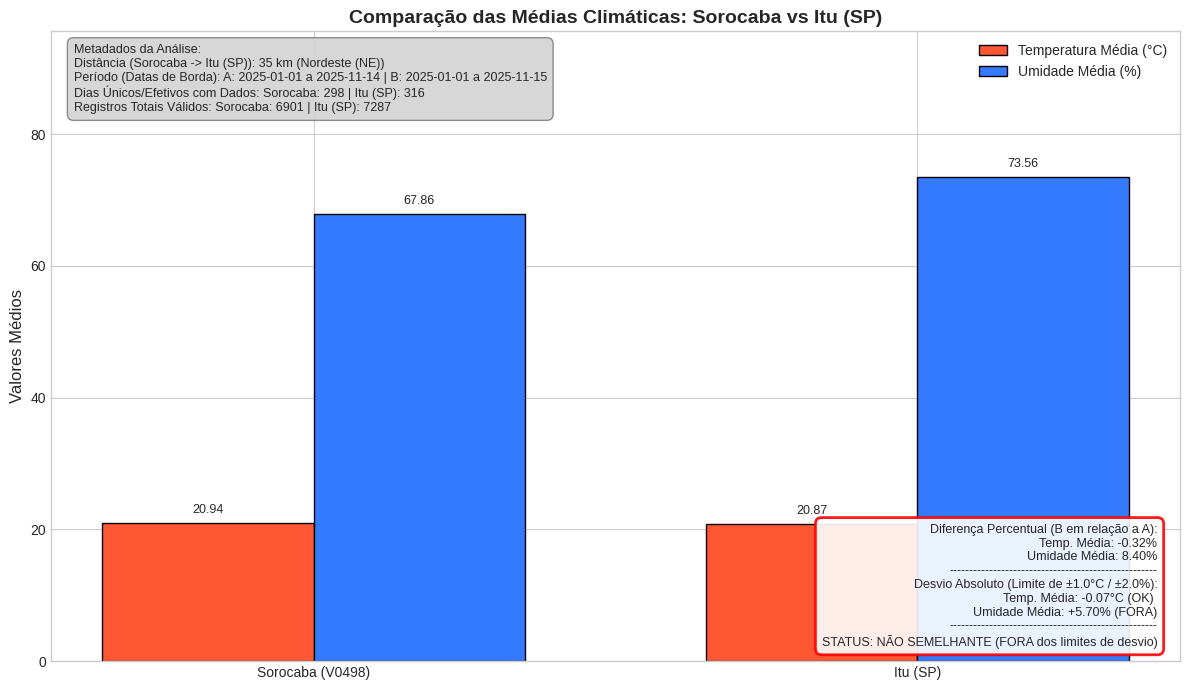

Gráfico de comparação salvo como 'comparacao_climatica_barras.png' no ambiente de execução.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
# Importações necessárias para o ambiente Google Colab
from google.colab import drive
import os
import numpy as np

# --- 1. CONFIGURAÇÕES E CAMINHOS ---

# C.1: Caminho do arquivo base (Sorocaba é a base A)
# ATENÇÃO: Verifique se este caminho está correto no seu Google Drive.
ARQUIVO_CIDADE_A = '/content/drive/MyDrive/Colab Notebooks/Estagio/Sorocaba.csv'
NOME_CIDADE_A = 'Sorocaba'
ESTACAO_ID_A = 'V0498' # Exemplo de ID da estação

# C.2: NOMES REAIS DAS COLUNAS DE TEMPERATURA E UMIDADE
# ATENÇÃO: Estes nomes DEVEM ser EXATOS aos cabeçalhos do seu arquivo CSV.
COLUNA_TEMP = 'Temp. Ins. (C)'
COLUNA_UMID = 'Umi. Ins. (%)'
COLUNA_DATA = 'Data'

# C.3: LIMITES DE DESVIO PARA APROVAÇÃO (CRITÉRIOS SOLICITADOS)
LIMITE_TEMP_DESVIO_C = 1.0 # Limite de desvio de Temperatura em Celsius (+/- 1°C)
LIMITE_UMID_DESVIO_PCT = 2.0 # Limite de desvio de Umidade em pontos percentuais (+/- 2%)

# C.4: METADADOS PREDEFINIDOS PARA CIDADES DE COMPARAÇÃO
# Estes dados são usados para preencher automaticamente a distância e direção no relatório.
# Adicione ou ajuste conforme a sua pesquisa.
CIDADES_METADADOS = {
    'Passos (MG)': {'distancia': 330, 'direcao': 'Norte/Nordeste (N/NE)'},
    'Juiz de Fora (MG)': {'distancia': 420, 'direcao': 'Leste (L)'},
    'Itu (SP)': {'distancia': 35, 'direcao': 'Nordeste (NE)'},
    'Campinas (SP)': {'distancia': 100, 'direcao': 'Nordeste (NE)'}
}

# Arquivo de saída para as médias
ARQUIVO_SAIDA = 'medias_comparativas.csv'

# Variáveis globais para dados de entrada (Serão preenchidas via input ou lookup)
ARQUIVO_CIDADE_B = None
NOME_CIDADE_B = None
DISTANCIA_KM = None
DIRECAO_ROSA_VENTOS = None

# --- 2. FUNÇÕES DE ANÁLISE ---

# [AJUSTE DE NOME]: Renomeado para 'dias_efetivos' para clareza
def obter_metadados_data(df, coluna_data):
    """
    Calcula a data de início (primeiro registro válido), data de fim (último
    registro válido) e o número de dias ÚNICOS e VÁLIDOS (dias efetivos).
    Isso exclui os 'gaps' de dias inteiros.
    """
    if df.empty:
        return 'N/A', 'N/A', 0

    # 1. Data de Início/Fim (Datas de Borda do primeiro e último registro)
    data_inicio = df[coluna_data].min().strftime('%Y-%m-%d')
    data_fim = df[coluna_data].max().strftime('%Y-%m-%d')

    # 2. Contagem de Dias Únicos Válidos (DIAS EFETIVOS - exclui Gaps)
    dias_efetivos = df[coluna_data].dt.date.nunique()

    return data_inicio, data_fim, dias_efetivos

def calcular_medias_e_diferencas(df_a, df_b, nome_a, nome_b):
    """
    Calcula as médias aritméticas e as diferenças entre as cidades A e B,
    baseado nos dados já filtrados.
    """
    # Cálculo das médias (o Pandas ignora automaticamente NaN's na média)
    media_temp_a = df_a[COLUNA_TEMP].mean()
    media_umid_a = df_a[COLUNA_UMID].mean()

    media_temp_b = df_b[COLUNA_TEMP].mean()
    media_umid_b = df_b[COLUNA_UMID].mean()

    # Diferença ABSOLUTA (B menos A)
    diff_abs_temp = (media_temp_b - media_temp_a)
    diff_abs_umid = (media_umid_b - media_umid_a)

    # Diferença Percentual (B em relação a A)
    diff_pct_temp = (diff_abs_temp / media_temp_a) * 100 if media_temp_a else 0
    diff_pct_umid = (diff_abs_umid / media_umid_a) * 100 if media_umid_a else 0

    # Dados formatados para o DataFrame de saída
    medias_a = {
        'Cidade': f'{nome_a} ({ESTACAO_ID_A})',
        'Temperatura Media (°C)': media_temp_a,
        'Umidade Media (%)': media_umid_a,
        'Data da Coleta': 'Média Aritmética Total'
    }

    medias_b = {
        'Cidade': nome_b,
        'Temperatura Media (°C)': media_temp_b,
        'Umidade Media (%)': media_umid_b,
        'Data da Coleta': 'Média Aritmética Total'
    }

    return medias_a, medias_b, diff_pct_temp, diff_pct_umid, diff_abs_temp, diff_abs_umid

# [AJUSTE DE NOME]: Renomeado parâmetro para 'dias_efetivos_a/b'
def gerar_grafico(df_medias, diff_pct_temp, diff_pct_umid, diff_abs_temp, diff_abs_umid, contagem_temp_a, contagem_umid_a, contagem_temp_b, contagem_umid_b, periodo_coleta, distancia, direcao, dias_efetivos_a, dias_efetivos_b):
    """
    Gera um gráfico de barras comparativo das médias e exibe as diferenças e metadados.
    Inclui as datas de borda e a contagem de dias efetivos.
    """
    cidades = df_medias['Cidade']
    temperaturas = df_medias['Temperatura']
    umidades = df_medias['Umidade']

    x = np.arange(len(cidades))
    largura = 0.35 # Largura das barras

    # Configuração do Gráfico
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7))

    # Barras de Temperatura
    rects1 = ax.bar(x - largura/2, temperaturas, largura,
                    label='Temperatura Média (°C)', color='#FF5733', edgecolor='black')

    # Barras de Umidade
    rects2 = ax.bar(x + largura/2, umidades, largura,
                    label='Umidade Média (%)', color='#337AFF', edgecolor='black')

    # Adiciona rótulos, título e legenda
    ax.set_ylabel('Valores Médios', fontsize=12)
    ax.set_title(f'Comparação das Médias Climáticas: {NOME_CIDADE_A} vs {NOME_CIDADE_B}', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(cidades, rotation=0, fontsize=10)
    ax.legend(loc='upper right', fontsize=10)

    # Ajusta o limite superior do eixo Y para criar espaço para a caixa de texto
    max_val = max(temperaturas.max(), umidades.max())
    ax.set_ylim(0, max_val * 1.30)

    # Função para adicionar o valor em cima da barra
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    autolabel(rects1)
    autolabel(rects2)

    # Lógica de Aprovação
    aprovado_temp = abs(diff_abs_temp) <= LIMITE_TEMP_DESVIO_C
    aprovado_umid = abs(diff_abs_umid) <= LIMITE_UMID_DESVIO_PCT

    if aprovado_temp and aprovado_umid:
        status_final = f"STATUS: SEMELHANTE (DENTRO dos limites de desvio)"
        status_cor = "green"
    else:
        status_final = f"STATUS: NÃO SEMELHANTE (FORA dos limites de desvio)"
        status_cor = "red"

    # Adiciona a caixa de texto com os metadados da análise (canto superior esquerdo)
    distancia_display = f"{distancia} km" if isinstance(distancia, (int, float)) else distancia

    # [AJUSTE NO TEXTO] Exibindo Datas de Borda e Dias Únicos/Efetivos separadamente
    texto_analise = (
        f"Metadados da Análise:\n"
        f"Distância ({NOME_CIDADE_A} -> {NOME_CIDADE_B}): {distancia_display} ({direcao})\n"
        f"Período (Datas de Borda): {periodo_coleta}\n"
        f"Dias Únicos/Efetivos com Dados: {NOME_CIDADE_A}: {dias_efetivos_a} | {NOME_CIDADE_B}: {dias_efetivos_b}\n"
        f"Registros Totais Válidos: {NOME_CIDADE_A}: {contagem_temp_a} | {NOME_CIDADE_B}: {contagem_temp_b}"
    )

    ax.text(0.02, 0.98, texto_analise, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle="round,pad=0.5", fc="lightgray", alpha=0.9, ec="gray"))

    # Caixa de diferença (Canto inferior direito) - Detalhando o critério
    texto_diff = (
        f"Diferença Percentual (B em relação a A):\n"
        f"Temp. Média: {diff_pct_temp:.2f}%\n"
        f"Umidade Média: {diff_pct_umid:.2f}%\n"
        f"----------------------------------------------------\n"
        f"Desvio Absoluto (Limite de ±{LIMITE_TEMP_DESVIO_C}°C / ±{LIMITE_UMID_DESVIO_PCT}%):\n"
        f"Temp. Média: {diff_abs_temp:+.2f}°C ({'OK' if aprovado_temp else 'FORA'}) \n"
        f"Umidade Média: {diff_abs_umid:+.2f}% ({'OK' if aprovado_umid else 'FORA'})\n"
        f"----------------------------------------------------\n"
        f"{status_final}"
    )

    ax.text(0.98, 0.02, texto_diff, transform=ax.transAxes,
            fontsize=9, verticalalignment='bottom', horizontalalignment='right',
            # Usa a cor do status para a borda
            bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.9, ec=status_cor, lw=2))

    # Salva o gráfico
    plt.tight_layout()
    plt.savefig('comparacao_climatica_barras.png')
    plt.show()

# --- 3. FLUXO PRINCIPAL DO PROGRAMA ---

def obter_dados_cidade_b():
    """
    Solicita o nome do arquivo e o nome da Cidade B ao usuário.
    Tenta preencher Distância e Direção automaticamente com base no nome.
    Se não encontrar, solicita a Distância e Direção manualmente.
    """
    print("\n" + "="*70)
    print(f"       CONFIGURAÇÃO DA CIDADE DE COMPARAÇÃO (Base: {NOME_CIDADE_A})")
    print("="*70)

    global ARQUIVO_CIDADE_B, NOME_CIDADE_B, DISTANCIA_KM, DIRECAO_ROSA_VENTOS

    print(f"ATENÇÃO: A cidade base (A) é {NOME_CIDADE_A}. O seu arquivo deve estar em:\n         '{ARQUIVO_CIDADE_A}'")

    # 1. Nome do arquivo da Cidade B (EXIGIDO)
    ARQUIVO_CIDADE_B_NOME = input(
        "1. Digite o NOME EXATO do arquivo CSV da Cidade B (ex: Campinas_1.csv): "
    )
    # Monta o caminho completo no Drive (assumindo o mesmo diretório base de Sorocaba)
    ARQUIVO_CIDADE_B = os.path.dirname(ARQUIVO_CIDADE_A) + "/" + ARQUIVO_CIDADE_B_NOME

    # 2. Nome da cidade (EXIGIDO para Lookup)
    NOME_CIDADE_B = input(
        "2. Digite o NOME COMPLETO da Cidade B para o gráfico e lookup (ex: Campinas (SP) ou Juiz de Fora (MG)): "
    ).strip() # O .strip() remove espaços extras

    # Tentativa de preenchimento automático
    metadado = CIDADES_METADADOS.get(NOME_CIDADE_B)

    if metadado:
        # AUTOMÁTICO: Cidade encontrada na lista
        DISTANCIA_KM = metadado['distancia']
        DIRECAO_ROSA_VENTOS = metadado['direcao']
        print(f"\n-> Metadados de distância e direção preenchidos automaticamente para '{NOME_CIDADE_B}'.")
    else:
        # MANUAL: Cidade não encontrada, solicita os dados
        print(f"\n-> Cidade '{NOME_CIDADE_B}' não encontrada na lista automática (C.4).")
        print("   Por favor, insira manualmente a distância e direção para o relatório.")

        # 3. Distância em linha reta (Solicita agora)
        DISTANCIA_KM = input(
            "3. Digite a distância APROXIMADA em linha reta (apenas o número em km, ex: 100): "
        )
        # 4. Direção (Solicita agora)
        DIRECAO_ROSA_VENTOS = input(
            "4. Digite a direção (ex: Nordeste (NE)): "
        )
        try:
            # Tenta limpar o input e converter para int
            DISTANCIA_KM = int(str(DISTANCIA_KM).split()[0].replace(',', '.'))
        except ValueError:
            print("AVISO: Distância não pôde ser convertida para número. Será salva como texto.")

        print("\n-> Dados de distância e direção preenchidos manualmente.")

    print("="*70 + "\n")


# FLUXO DE EXECUÇÃO
print("Iniciando a Análise Climática em ambiente Colab.")

# 3.1. Montagem do Google Drive (Necessário para acessar os arquivos)
try:
    print("Tentando montar o Google Drive...")
    # force_remount=True ajuda a evitar problemas de sessão
    drive.mount('/content/drive', force_remount=True)
    print("Google Drive montado com sucesso.")
except Exception as e:
    print(f"ERRO ao montar o Drive: {e}. Certifique-se de que está no Google Colab.")
    exit() # Interrompe a execução se não conseguir montar o Drive

# 3.2. Solicita os dados da Cidade B
obter_dados_cidade_b()

try:
    # 3.3. Leitura dos Dados
    # Usando sep=';' e decimal=',' (comum em CSVs brasileiros)
    df_a = pd.read_csv(ARQUIVO_CIDADE_A, sep=';', decimal=',')
    df_b = pd.read_csv(ARQUIVO_CIDADE_B, sep=';', decimal=',')

    print("\n--- Dados de Entrada Lidos com Sucesso ---")

    # Garante que as colunas de data são datetime
    df_a[COLUNA_DATA] = pd.to_datetime(df_a[COLUNA_DATA], errors='coerce', format='%d/%m/%Y')
    df_b[COLUNA_DATA] = pd.to_datetime(df_b[COLUNA_DATA], errors='coerce', format='%d/%m/%Y')

    # --- FILTRAGEM MAIS RIGOROSA (Passo essencial) ---
    # Remove registros onde a data É inválida OU os dados de Temp/Umid SÃO nulos
    colunas_filtro = [COLUNA_DATA, COLUNA_TEMP, COLUNA_UMID]

    # Filtrando Cidade A
    total_registros_a = len(df_a)
    df_a.dropna(subset=colunas_filtro, inplace=True)
    contagem_temp_a = df_a[COLUNA_TEMP].count()
    contagem_umid_a = df_a[COLUNA_UMID].count()

    # Filtrando Cidade B
    total_registros_b = len(df_b)
    df_b.dropna(subset=colunas_filtro, inplace=True)
    contagem_temp_b = df_b[COLUNA_TEMP].count()
    contagem_umid_b = df_b[COLUNA_UMID].count()

    # [REVISÃO] Cálculo das Datas de Borda e Dias Efetivos/Únicos
    # As datas retornadas são as datas do primeiro e último registro VÁLIDO.
    data_inicio_a, data_fim_a, dias_efetivos_a = obter_metadados_data(df_a, COLUNA_DATA)
    data_inicio_b, data_fim_b, dias_efetivos_b = obter_metadados_data(df_b, COLUNA_DATA)

    # [REVISÃO] Formatando a string do período de coleta (Datas de Borda)
    if data_inicio_a == data_inicio_b and data_fim_a == data_fim_b:
        periodo_coleta = f"{data_inicio_a} a {data_fim_a}"
    else:
        periodo_coleta = f"A: {data_inicio_a} a {data_fim_a} | B: {data_inicio_b} a {data_fim_b}"

    print(f"\n--- Metadados da Coleta (Após Filtragem) ---")
    print(f"Datas de Coleta (Primeiro/Último Reg. Válido): {periodo_coleta}")
    print(f"Total de Dias Únicos com Dados: {NOME_CIDADE_A}: {dias_efetivos_a} | {NOME_CIDADE_B}: {dias_efetivos_b}")
    print(f"Registros Totais VÁLIDOS (Temp/Umid): {NOME_CIDADE_A}: {contagem_temp_a} | {NOME_CIDADE_B}: {contagem_temp_b}")
    print(f"Registros REMOVIDOS (Gaps/Inválidos): {NOME_CIDADE_A}: {total_registros_a - contagem_temp_a} | {NOME_CIDADE_B}: {total_registros_b - contagem_temp_b}")
    print(f"Distância: {DISTANCIA_KM} km | Direção: {DIRECAO_ROSA_VENTOS}\n")

    # 3.4. Cálculo das Médias e Diferenças
    medias_a, medias_b, diff_pct_temp, diff_pct_umid, diff_abs_temp, diff_abs_umid = calcular_medias_e_diferencas(
        df_a, df_b, NOME_CIDADE_A, NOME_CIDADE_B
    )

    # 3.5. Criação da Tabela de Médias Comparativas
    df_medias = pd.DataFrame([medias_a, medias_b])

    df_medias.rename(columns={
        'Temperatura Media (°C)': 'Temperatura',
        'Umidade Media (%)': 'Umidade',
        'Data da Coleta': 'Data'
    }, inplace=True)

    # 3.6. Salvamento da Tabela de Médias
    df_medias.to_csv(ARQUIVO_SAIDA, index=False, sep=';', decimal=',')

    print(f"--- Tabela de Médias Salva no Drive ({ARQUIVO_SAIDA}) ---")
    print(df_medias.to_markdown(index=False))
    print("\n")

    # 3.7. Geração do Gráfico e Relatório Final
    # [AJUSTE DE NOME]: Passando as novas contagens de dias efetivos
    gerar_grafico(
        df_medias,
        diff_pct_temp,
        diff_pct_umid,
        diff_abs_temp,
        diff_abs_umid,
        contagem_temp_a,
        contagem_umid_a,
        contagem_temp_b,
        contagem_umid_b,
        periodo_coleta,
        DISTANCIA_KM,
        DIRECAO_ROSA_VENTOS,
        dias_efetivos_a, # Novo parâmetro (dias únicos sem gaps)
        dias_efetivos_b  # Novo parâmetro (dias únicos sem gaps)
    )
    print("Gráfico de comparação salvo como 'comparacao_climatica_barras.png' no ambiente de execução.")

except FileNotFoundError:
    print(f"\nERRO: Um dos arquivos CSV não foi encontrado. Verifique os caminhos:")
    print(f"Arquivo A (Sorocaba): '{ARQUIVO_CIDADE_A}'")
    print(f"Arquivo B ({NOME_CIDADE_B}): '{ARQUIVO_CIDADE_B}'")
    print("Certifique-se de que o Google Drive está montado e os nomes estão exatos.")
except KeyError as e:
    print(f"\nERRO DE COLUNA: Coluna '{e}' não encontrada nos seus arquivos CSV.")
    print(f"Verifique as variáveis COLUNA_TEMP, COLUNA_UMID e COLUNA_DATA no início do código (seção C.2) e ajuste para os nomes exatos das colunas do seu CSV.")
except Exception as e:
    print(f"\nOcorreu um erro inesperado durante a execução: {e}")